## Feature Engineering - 1

### House pricing Dataset

In [1]:
## House pricing Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
df = pd.read_csv("train.csv")


In [3]:
df.shape

(1460, 81)

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Feature Engineering

#### Drop irrelevant columns

In [5]:
df = df.drop(columns = ['Id'],errors = 'ignore')
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Handling missing data

In [6]:
# Check missing values count
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [7]:
## finding the columns with missing values

missing_percentage = df.isnull().mean().sort_values(ascending=False)
missing_percentage 

PoolQC           0.995205
MiscFeature      0.963014
Alley            0.937671
Fence            0.807534
MasVnrType       0.597260
                   ...   
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
SalePrice        0.000000
Length: 80, dtype: float64

In [8]:
## columns with high missing values
threshold = 0.65
columns_with_high_missing_values = missing_percentage[missing_percentage > threshold].index.tolist()

In [9]:
columns_with_high_missing_values

['PoolQC', 'MiscFeature', 'Alley', 'Fence']

In [10]:
df_1 = df.drop(columns = columns_with_high_missing_values, errors = 'ignore')
df_1.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [11]:
df_1.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF'

In [12]:
df_1.shape

(1460, 76)

## filter by importance

 - Correlation with salesprices

In [13]:
df_1.select_dtypes(include=np.number).corr()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,-0.065649,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378


In [14]:
## the correlation with respect to the sales price

target_correlation = df_1.select_dtypes(include=np.number).corr()['SalePrice'].abs()
target_correlation

MSSubClass       0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond      0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2       0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF     0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath     0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch    0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal          0.021190
MoSold           0.046432
YrSold           0.028923
SalePrice        1.000000
Name: SalePrice, dtype: float64

In [15]:
low_impact_threshold_cor  = 0.1 

## always use correlation

low_impact_columns = target_correlation[target_correlation < low_impact_threshold_cor].index.tolist()
low_impact_columns

['MSSubClass',
 'OverallCond',
 'BsmtFinSF2',
 'LowQualFinSF',
 'BsmtHalfBath',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [16]:
df_2 = df_1.drop(columns = low_impact_columns, errors = 'ignore')
df_2.shape

(1460, 66)

In [17]:
# Removing multi-collinearity

corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()
corr_matrix



,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,0.386347,0.139781,0.032628,0.059316,0.027850,0.040581,0.022936,0.069836,0.065649,...,0.012579,0.006100,0.012037,0.043825,0.026030,0.008283,0.007683,0.013585,0.021407,0.084284
LotFrontage,0.386347,1.000000,0.426095,0.251646,0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,0.139781,0.426095,1.000000,0.105806,0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,0.014261,0.263843
OverallQual,0.032628,0.251646,0.105806,1.000000,0.091932,0.572323,0.550684,0.411876,0.239666,0.059119,...,0.238923,0.308819,0.113937,0.030371,0.064886,0.065166,0.031406,0.070815,0.027347,0.790982
OverallCond,0.059316,0.059213,0.005636,0.091932,1.000000,0.375983,0.073741,0.128101,0.046231,0.040229,...,0.003334,0.032589,0.070356,0.025504,0.054811,0.001985,0.068777,0.003511,0.043950,0.077856
YearBuilt,0.027850,0.123349,0.014228,0.572323,0.375983,1.000000,0.592855,0.315707,0.249503,0.049107,...,0.224880,0.188686,0.387268,0.031355,0.050364,0.004950,0.034383,0.012398,0.013618,0.522897
YearRemodAdd,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,0.067759,...,0.205726,0.226298,0.193919,0.045286,0.038740,0.005829,0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.022936,0.193458,0.104160,0.411876,0.128101,0.315707,0.179618,1.000000,0.264736,0.072319,...,0.159718,0.125703,0.110204,0.018796,0.061466,0.011723,0.029815,0.005965,0.008201,0.477493
BsmtFinSF1,0.069836,0.233633,0.214103,0.239666,0.046231,0.249503,0.128451,0.264736,1.000000,0.050117,...,0.204306,0.111761,0.102303,0.026451,0.062021,0.140491,0.003571,0.015727,0.014359,0.386420
BsmtFinSF2,0.065649,0.049900,0.111170,0.059119,0.040229,0.049107,0.067759,0.072319,0.050117,1.000000,...,0.067898,0.003093,0.036543,0.029993,0.088871,0.041709,0.004940,0.015211,0.031706,0.011378


In [18]:
np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

array([[False,  True,  True, ...,  True,  True,  True],
       [False, False,  True, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       ...,
       [False, False, False, ..., False,  True,  True],
       [False, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False, False]], shape=(37, 37))

In [19]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
upper

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,NaN,0.386347,0.139781,0.032628,0.059316,0.027850,0.040581,0.022936,0.069836,0.065649,...,0.012579,0.006100,0.012037,0.043825,0.026030,0.008283,0.007683,0.013585,0.021407,0.084284
LotFrontage,NaN,NaN,0.426095,0.251646,0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,NaN,NaN,NaN,0.105806,0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,0.014261,0.263843
OverallQual,NaN,NaN,NaN,NaN,0.091932,0.572323,0.550684,0.411876,0.239666,0.059119,...,0.238923,0.308819,0.113937,0.030371,0.064886,0.065166,0.031406,0.070815,0.027347,0.790982
OverallCond,NaN,NaN,NaN,NaN,NaN,0.375983,0.073741,0.128101,0.046231,0.040229,...,0.003334,0.032589,0.070356,0.025504,0.054811,0.001985,0.068777,0.003511,0.043950,0.077856
YearBuilt,NaN,NaN,NaN,NaN,NaN,NaN,0.592855,0.315707,0.249503,0.049107,...,0.224880,0.188686,0.387268,0.031355,0.050364,0.004950,0.034383,0.012398,0.013618,0.522897
YearRemodAdd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.179618,0.128451,0.067759,...,0.205726,0.226298,0.193919,0.045286,0.038740,0.005829,0.010286,0.021490,0.035743,0.507101
MasVnrArea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.264736,0.072319,...,0.159718,0.125703,0.110204,0.018796,0.061466,0.011723,0.029815,0.005965,0.008201,0.477493
BsmtFinSF1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.050117,...,0.204306,0.111761,0.102303,0.026451,0.062021,0.140491,0.003571,0.015727,0.014359,0.386420
BsmtFinSF2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.067898,0.003093,0.036543,0.029993,0.088871,0.041709,0.004940,0.015211,0.031706,0.011378


In [20]:
for column in upper.columns:
    print(column)

MSSubClass
LotFrontage
LotArea
OverallQual
OverallCond
YearBuilt
YearRemodAdd
MasVnrArea
BsmtFinSF1
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
TotRmsAbvGrd
Fireplaces
GarageYrBlt
GarageCars
GarageArea
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
MiscVal
MoSold
YrSold
SalePrice


In [21]:
redundant_cols = [column for column in upper.columns if any(upper[column] > 0.8)]
print(redundant_cols)

## removing redundant columns

['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']


In [22]:
df_3 = df_2.drop(columns = redundant_cols, errors = 'ignore')
df_3.shape

(1460, 62)

# Part 2

In [23]:
df_3

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [24]:
df_3.shape

(1460, 62)

In [25]:
# Check missing values count
missing_values = df_3.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageType       81
GarageQual       81
GarageFinish     81
GarageCond       81
BsmtFinType2     38
BsmtExposure     38
BsmtQual         37
BsmtFinType1     37
BsmtCond         37
MasVnrArea        8
Electrical        1
dtype: int64


# Handling missing values 

## 1. Simple Imputation

Instead of deleting, we fill the missing values with estimates

(a). Mean imputation ((numerical data))

(b). Median imputation (numerical data)

(c). Mode imputation (categorical data)


In [26]:
## simple imputation (MEAN Imputation)

# this pulls the distribution towards the mean ---> underestimates the variance

df_mean = df_3.copy()
df_mean.fillna({"LotFrontage": df_mean["LotFrontage"].mean()}, inplace=True)

df_mean

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [27]:
## simple imputation (Median Imputation)

# robust for outliers

df_median = df_3.copy()
df_median.fillna({"LotFrontage": df_median["LotFrontage"].median()}, inplace=True)
df_median

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [28]:
## simple imputation (Mode Imputation)

# highest frequency

df_mode = df_3.copy()
df_mode["GarageType"].unique()


<ArrowStringArray>
['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types']
Length: 7, dtype: str

In [29]:
df_mode.fillna({"GarageType": df_mode["GarageType"].mode()[0]}, inplace=True)
df_mode

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


### Compare before and after imputation

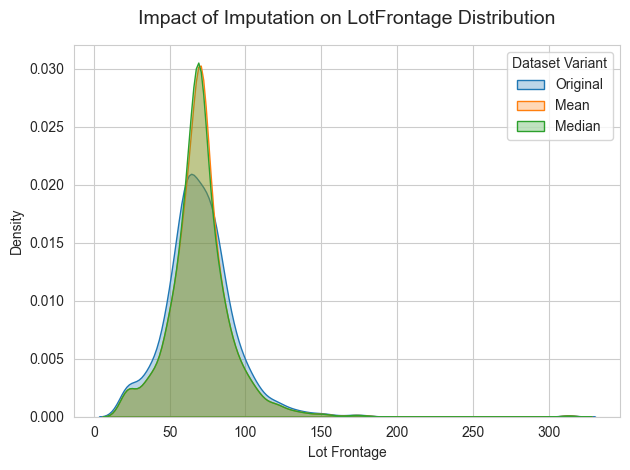

In [30]:
# Set a clean visual style
sns.set_style("whitegrid")
plt.Figure(figsize=(10,5))

sns.kdeplot(df["LotFrontage"], label = "Original", fill= True, alpha=0.3)
sns.kdeplot(df_mean["LotFrontage"], label = "Mean", fill= True, alpha=0.3)
sns.kdeplot(df_median["LotFrontage"], label = "Median", fill= True, alpha=0.3)
# Enhancing readability
plt.title("Impact of Imputation on LotFrontage Distribution", fontsize=14, pad=15)
plt.xlabel("Lot Frontage")
plt.ylabel("Density")
plt.legend(title="Dataset Variant")

plt.tight_layout()
plt.show()

## 2. KNN IMPUTATION

K- NEAREST NEIGHBOR  - ML Algorithm

- Select the number of nearest neighbor it has to be odd. could be (3,5,7,9,11 etc)
- find Euclidean distance and select the least distance.

In [31]:
from sklearn.impute import KNNImputer

In [32]:
KNN_imputation = KNNImputer(n_neighbors= 5)

In [33]:
df_knn = df_3.copy()

In [34]:
numerical_cols = df_knn.select_dtypes(include=[np.number]).columns
numerical_cols

Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF',
       'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='str')

In [35]:
df_knn[numerical_cols] = KNN_imputation.fit_transform(df_knn[numerical_cols])

In [36]:
df_knn[numerical_cols]

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,2ndFlrSF,...,HalfBath,BedroomAbvGr,KitchenAbvGr,Fireplaces,GarageCars,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice
0,65.0,8450.0,7.0,2003.0,2003.0,196.0,706.0,150.0,856.0,854.0,...,1.0,3.0,1.0,0.0,2.0,0.0,61.0,0.0,0.0,208500.0
1,80.0,9600.0,6.0,1976.0,1976.0,0.0,978.0,284.0,1262.0,0.0,...,0.0,3.0,1.0,1.0,2.0,298.0,0.0,0.0,0.0,181500.0
2,68.0,11250.0,7.0,2001.0,2002.0,162.0,486.0,434.0,920.0,866.0,...,1.0,3.0,1.0,1.0,2.0,0.0,42.0,0.0,0.0,223500.0
3,60.0,9550.0,7.0,1915.0,1970.0,0.0,216.0,540.0,756.0,756.0,...,0.0,3.0,1.0,1.0,3.0,0.0,35.0,272.0,0.0,140000.0
4,84.0,14260.0,8.0,2000.0,2000.0,350.0,655.0,490.0,1145.0,1053.0,...,1.0,4.0,1.0,1.0,3.0,192.0,84.0,0.0,0.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,62.0,7917.0,6.0,1999.0,2000.0,0.0,0.0,953.0,953.0,694.0,...,1.0,3.0,1.0,1.0,2.0,0.0,40.0,0.0,0.0,175000.0
1456,85.0,13175.0,6.0,1978.0,1988.0,119.0,790.0,589.0,1542.0,0.0,...,0.0,3.0,1.0,2.0,2.0,349.0,0.0,0.0,0.0,210000.0
1457,66.0,9042.0,7.0,1941.0,2006.0,0.0,275.0,877.0,1152.0,1152.0,...,0.0,4.0,1.0,2.0,1.0,0.0,60.0,0.0,0.0,266500.0
1458,68.0,9717.0,5.0,1950.0,1996.0,0.0,49.0,0.0,1078.0,0.0,...,0.0,2.0,1.0,0.0,1.0,366.0,0.0,112.0,0.0,142125.0


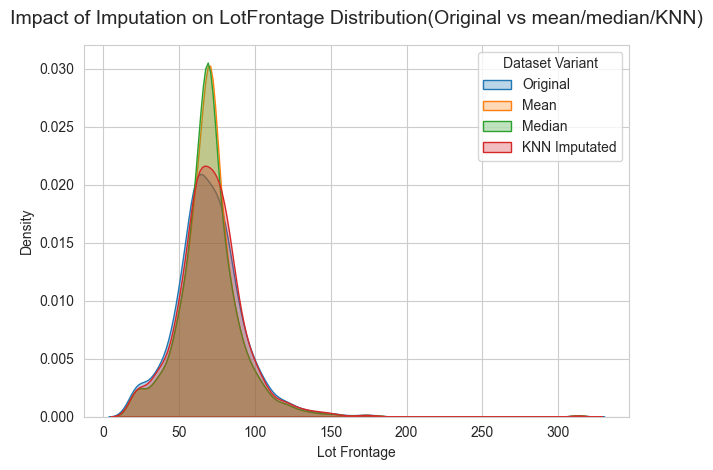

In [37]:
# Set a clean visual style
sns.set_style("whitegrid")
plt.Figure(figsize=(10,5))

sns.kdeplot(df["LotFrontage"], label = "Original", fill= True, alpha=0.3)
sns.kdeplot(df_mean["LotFrontage"], label = "Mean", fill= True, alpha=0.3)
sns.kdeplot(df_median["LotFrontage"], label = "Median", fill= True, alpha=0.3)
sns.kdeplot(df_knn["LotFrontage"], label = "KNN Imputated", fill= True, alpha=0.3)
# Enhancing readability
plt.title("Impact of Imputation on LotFrontage Distribution(Original vs mean/median/KNN)", fontsize=14, pad=15)
plt.xlabel("Lot Frontage")
plt.ylabel("Density")
plt.legend(title="Dataset Variant")

plt.tight_layout()
plt.show()

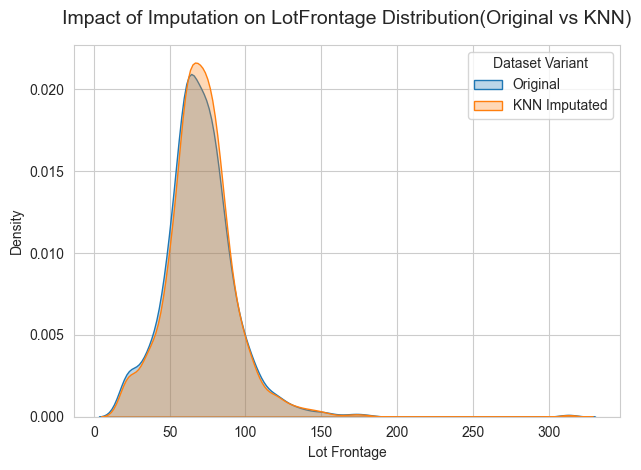

In [38]:
# Set a clean visual style
sns.set_style("whitegrid")
plt.Figure(figsize=(10,5))

sns.kdeplot(df["LotFrontage"], label = "Original", fill= True, alpha=0.3)
###sns.kdeplot(df_mean["LotFrontage"], label = "Mean", fill= True, alpha=0.3)
##sns.kdeplot(df_median["LotFrontage"], label = "Median", fill= True, alpha=0.3)
sns.kdeplot(df_knn["LotFrontage"], label = "KNN Imputated", fill= True, alpha=0.3)
# Enhancing readability
plt.title("Impact of Imputation on LotFrontage Distribution(Original vs KNN)", fontsize=14, pad=15)
plt.xlabel("Lot Frontage")
plt.ylabel("Density")
plt.legend(title="Dataset Variant")

plt.tight_layout()
plt.show()

In [39]:
def compare_imputation(df_before, df_after, column_name):
    missing_indices = {column_name : df_before[df_before[column_name].isnull()].index.to_list() for column_name in df_before.columns if df_before[column_name].isnull().any()}

    if column_name not in missing_indices:
        print(f"No missing values were found in column '{column_name}'")
        return

    idx_list = missing_indices[column_name]

    comparison = pd.DataFrame({
        "Before" : df_before.loc[idx_list,column_name], 
        "After" : df_after.loc[idx_list,column_name], 
    })

    print(f"Changes in column : {column_name}")
    return comparison


In [40]:
compare_imputation(df_3, df_knn, "LotFrontage")

Changes in column : LotFrontage


,Before,After
7,NaN,77.4
12,NaN,73.2
14,NaN,75.2
16,NaN,90.2
24,NaN,66.0
...,...,...
1429,NaN,82.2
1431,NaN,52.6
1441,NaN,34.2
1443,NaN,61.0


## Feature Engineering 3

## 3. Regression Imputation (Advance)

In [41]:
from sklearn.linear_model import LinearRegression

In [42]:
df_reg = df_3.copy()
df_reg.head()

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000


In [43]:
missing_values_reg = df_reg.isnull().sum()
missing_values_reg = missing_values_reg[missing_values_reg > 0].sort_values(ascending=False)
print(missing_values_reg)

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageType       81
GarageQual       81
GarageFinish     81
GarageCond       81
BsmtFinType2     38
BsmtExposure     38
BsmtQual         37
BsmtFinType1     37
BsmtCond         37
MasVnrArea        8
Electrical        1
dtype: int64


In [44]:
train_data = df_reg.dropna(subset=["LotFrontage"]) ## drop the rows where lotfrontage are null values
test_data = df_reg[df_reg["LotFrontage"].isnull()]

In [45]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 1201 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1201 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1201 non-null   int64  
 3   Street         1201 non-null   str    
 4   LotShape       1201 non-null   str    
 5   LandContour    1201 non-null   str    
 6   Utilities      1201 non-null   str    
 7   LotConfig      1201 non-null   str    
 8   LandSlope      1201 non-null   str    
 9   Neighborhood   1201 non-null   str    
 10  Condition1     1201 non-null   str    
 11  Condition2     1201 non-null   str    
 12  BldgType       1201 non-null   str    
 13  HouseStyle     1201 non-null   str    
 14  OverallQual    1201 non-null   int64  
 15  YearBuilt      1201 non-null   int64  
 16  YearRemodAdd   1201 non-null   int64  
 17  RoofStyle      1201 non-null   str    
 18  RoofMatl       1201 non-

In [50]:
## to get the columns that are correlated to LotFrontage
target_correlation_ml = train_data.select_dtypes(include=np.number).corr()['LotFrontage'].abs()
target_correlation_ml

LotFrontage      1.000000
LotArea          0.426095
OverallQual      0.251646
YearBuilt        0.123349
YearRemodAdd     0.088866
MasVnrArea       0.193458
BsmtFinSF1       0.233633
BsmtUnfSF        0.132644
TotalBsmtSF      0.392075
2ndFlrSF         0.080177
GrLivArea        0.402797
BsmtFullBath     0.100949
FullBath         0.198769
HalfBath         0.053532
BedroomAbvGr     0.263170
KitchenAbvGr     0.006069
Fireplaces       0.266639
GarageCars       0.285691
WoodDeckSF       0.088521
OpenPorchSF      0.151972
EnclosedPorch    0.010700
ScreenPorch      0.041383
SalePrice        0.351799
Name: LotFrontage, dtype: float64

In [49]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 1201 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1201 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1201 non-null   int64  
 3   Street         1201 non-null   str    
 4   LotShape       1201 non-null   str    
 5   LandContour    1201 non-null   str    
 6   Utilities      1201 non-null   str    
 7   LotConfig      1201 non-null   str    
 8   LandSlope      1201 non-null   str    
 9   Neighborhood   1201 non-null   str    
 10  Condition1     1201 non-null   str    
 11  Condition2     1201 non-null   str    
 12  BldgType       1201 non-null   str    
 13  HouseStyle     1201 non-null   str    
 14  OverallQual    1201 non-null   int64  
 15  YearBuilt      1201 non-null   int64  
 16  YearRemodAdd   1201 non-null   int64  
 17  RoofStyle      1201 non-null   str    
 18  RoofMatl       1201 non-

In [51]:
X_train = train_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]] ## selected correlated ones
y_train = train_data["LotFrontage"]

In [52]:
reg = LinearRegression()

In [53]:
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
reg.coef_

array([ 8.90135199e-04, -1.49550808e+00,  1.24430130e-02,  1.16904327e-02])

In [56]:
test_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]].info()

<class 'pandas.DataFrame'>
Index: 259 entries, 7 to 1446
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LotArea      259 non-null    int64
 1   OverallQual  259 non-null    int64
 2   TotalBsmtSF  259 non-null    int64
 3   GrLivArea    259 non-null    int64
dtypes: int64(4)
memory usage: 10.1 KB


In [57]:
## predicting Y (LOTFRONTAGE) using the testing data which are null
df_reg.loc[df_reg['LotFrontage'].isnull(), "LotFrontage"] = reg.predict(test_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]])

In [58]:
compare_imputation(df_3, df_reg, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,76.480215
12,NaN,65.575403
14,NaN,70.486403
16,NaN,64.762909
24,NaN,64.943935
31,NaN,69.263614
42,NaN,60.980342
43,NaN,62.848844
50,NaN,69.936893
64,NaN,74.307034


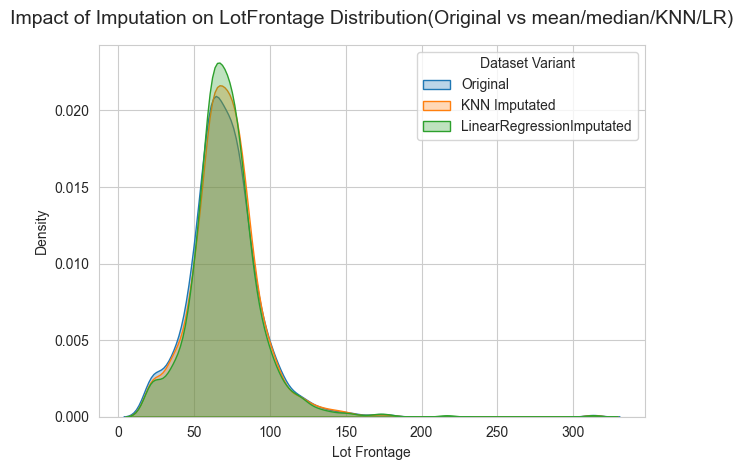

In [60]:
# Set a clean visual style
sns.set_style("whitegrid")
plt.Figure(figsize=(10,5))

sns.kdeplot(df["LotFrontage"], label = "Original", fill= True, alpha=0.3)
#sns.kdeplot(df_mean["LotFrontage"], label = "Mean", fill= True, alpha=0.3)
#sns.kdeplot(df_median["LotFrontage"], label = "Median", fill= True, alpha=0.3)
sns.kdeplot(df_knn["LotFrontage"], label = "KNN Imputated", fill= True, alpha=0.3)
sns.kdeplot(df_reg["LotFrontage"], label = "LinearRegressionImputated", fill= True, alpha=0.3)
# Enhancing readability
plt.title("Impact of Imputation on LotFrontage Distribution(Original vs mean/median/KNN/LR)", fontsize=14, pad=15)
plt.xlabel("Lot Frontage")
plt.ylabel("Density")
plt.legend(title="Dataset Variant")

plt.tight_layout()
plt.show()

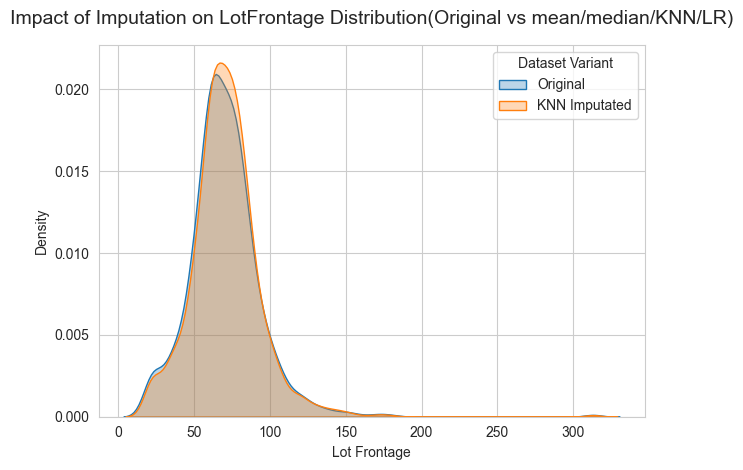

In [62]:
# Set a clean visual style
sns.set_style("whitegrid")
plt.Figure(figsize=(10,5))

sns.kdeplot(df["LotFrontage"], label = "Original", fill= True, alpha=0.3)
#sns.kdeplot(df_mean["LotFrontage"], label = "Mean", fill= True, alpha=0.3)
#sns.kdeplot(df_median["LotFrontage"], label = "Median", fill= True, alpha=0.3)
sns.kdeplot(df_knn["LotFrontage"], label = "KNN Imputated", fill= True, alpha=0.3)
#sns.kdeplot(df_reg["LotFrontage"], label = "LinearRegressionImputated", fill= True, alpha=0.3)
# Enhancing readability
plt.title("Impact of Imputation on LotFrontage Distribution(Original vs mean/median/KNN/LR)", fontsize=14, pad=15)
plt.xlabel("Lot Frontage")
plt.ylabel("Density")
plt.legend(title="Dataset Variant")

plt.tight_layout()
plt.show()

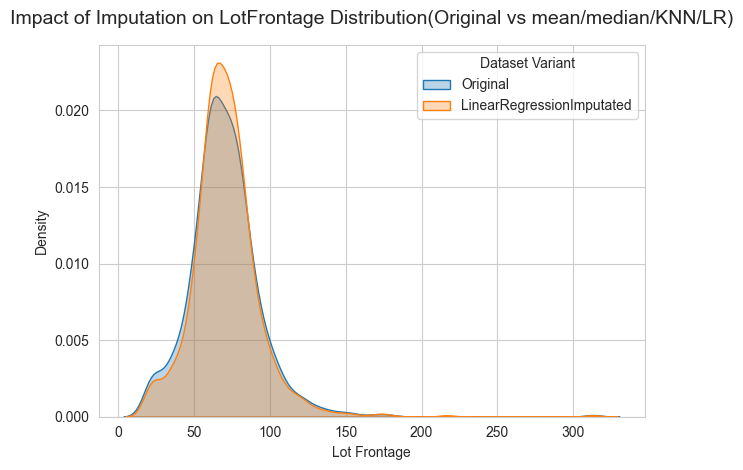

In [61]:
# Set a clean visual style
sns.set_style("whitegrid")
plt.Figure(figsize=(10,5))

sns.kdeplot(df["LotFrontage"], label = "Original", fill= True, alpha=0.3)
#sns.kdeplot(df_mean["LotFrontage"], label = "Mean", fill= True, alpha=0.3)
#sns.kdeplot(df_median["LotFrontage"], label = "Median", fill= True, alpha=0.3)
#sns.kdeplot(df_knn["LotFrontage"], label = "KNN Imputated", fill= True, alpha=0.3)
sns.kdeplot(df_reg["LotFrontage"], label = "LinearRegressionImputated", fill= True, alpha=0.3)
# Enhancing readability
plt.title("Impact of Imputation on LotFrontage Distribution(Original vs mean/median/KNN/LR)", fontsize=14, pad=15)
plt.xlabel("Lot Frontage")
plt.ylabel("Density")
plt.legend(title="Dataset Variant")

plt.tight_layout()
plt.show()

## Filling missing values using Iterative imputater (MICE)

In [63]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

In [64]:
cols_to_use = ["LotFrontage","LotArea", "OverallQual", "GrLivArea"]

In [65]:
df_subset = df_3[cols_to_use].copy()

In [66]:
iter_imput = IterativeImputer(estimator=LinearRegression(), max_iter=10,random_state=10)

In [67]:
df_subset_imputed_values = iter_imput.fit_transform(df_subset)

In [68]:
df_subset_imputed_values

array([[6.500e+01, 8.450e+03, 7.000e+00, 1.710e+03],
       [8.000e+01, 9.600e+03, 6.000e+00, 1.262e+03],
       [6.800e+01, 1.125e+04, 7.000e+00, 1.786e+03],
       ...,
       [6.600e+01, 9.042e+03, 7.000e+00, 2.340e+03],
       [6.800e+01, 9.717e+03, 5.000e+00, 1.078e+03],
       [7.500e+01, 9.937e+03, 5.000e+00, 1.256e+03]], shape=(1460, 4))

In [70]:
df_subset[cols_to_use] = df_subset_imputed_values

In [72]:
df_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1460 non-null   float64
 1   LotArea      1460 non-null   float64
 2   OverallQual  1460 non-null   float64
 3   GrLivArea    1460 non-null   float64
dtypes: float64(4)
memory usage: 45.8 KB


In [73]:
df_subset.head()

,LotFrontage,LotArea,OverallQual,GrLivArea
0,65.0,8450.0,7.0,1710.0
1,80.0,9600.0,6.0,1262.0
2,68.0,11250.0,7.0,1786.0
3,60.0,9550.0,7.0,1717.0
4,84.0,14260.0,8.0,2198.0


### using it on the full dataset

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [74]:
cols_to_use_df =  ["LotFrontage", "LotArea", "OverallQual", "OverallCond", "1stFlrSF", "GrLivArea", "GarageYrBlt", "MasVnrArea"]

In [75]:
df[cols_to_use_df].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1201 non-null   float64
 1   LotArea      1460 non-null   int64  
 2   OverallQual  1460 non-null   int64  
 3   OverallCond  1460 non-null   int64  
 4   1stFlrSF     1460 non-null   int64  
 5   GrLivArea    1460 non-null   int64  
 6   GarageYrBlt  1379 non-null   float64
 7   MasVnrArea   1452 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 91.4 KB


In [78]:
df_subset_df = df[cols_to_use_df].copy()

In [79]:
df_subset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1201 non-null   float64
 1   LotArea      1460 non-null   int64  
 2   OverallQual  1460 non-null   int64  
 3   OverallCond  1460 non-null   int64  
 4   1stFlrSF     1460 non-null   int64  
 5   GrLivArea    1460 non-null   int64  
 6   GarageYrBlt  1379 non-null   float64
 7   MasVnrArea   1452 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 91.4 KB


In [80]:
iter_imput_df = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=10)

In [81]:
df_subset_imputed_values_df = iter_imput.fit_transform(df_subset_df)

In [82]:
df_subset_df[cols_to_use_df] = df_subset_imputed_values_df

In [83]:
df_subset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1460 non-null   float64
 1   LotArea      1460 non-null   float64
 2   OverallQual  1460 non-null   float64
 3   OverallCond  1460 non-null   float64
 4   1stFlrSF     1460 non-null   float64
 5   GrLivArea    1460 non-null   float64
 6   GarageYrBlt  1460 non-null   float64
 7   MasVnrArea   1460 non-null   float64
dtypes: float64(8)
memory usage: 91.4 KB


## Handling Outliers

Outliers represent errors, rare cases and important scenarios

#### Methods to detect and handle Outliers
1. Visualization (boxplot).
2. IQR Method (Range)
3. Z-Score
4. Capping extreme values (Winsorization)

In [85]:
df_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1460 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   str    
 4   LotShape       1460 non-null   str    
 5   LandContour    1460 non-null   str    
 6   Utilities      1460 non-null   str    
 7   LotConfig      1460 non-null   str    
 8   LandSlope      1460 non-null   str    
 9   Neighborhood   1460 non-null   str    
 10  Condition1     1460 non-null   str    
 11  Condition2     1460 non-null   str    
 12  BldgType       1460 non-null   str    
 13  HouseStyle     1460 non-null   str    
 14  OverallQual    1460 non-null   int64  
 15  YearBuilt      1460 non-null   int64  
 16  YearRemodAdd   1460 non-null   int64  
 17  RoofStyle      1460 non-null   str    
 18  RoofMatl       1460

In [86]:
df = df_3.copy()

#### 1. Visualization of Outliers

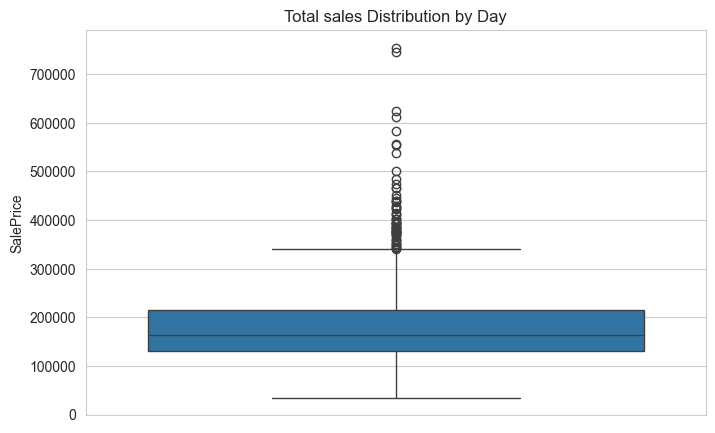

In [ ]:
# Create the box plot

plt.figure(figsize=(8,5))
# x = categorical data, y = numerical data
sns.boxplot(data=df["SalePrice"])

# Show the plot
plt.title("Boxplot of sales")
plt.show()

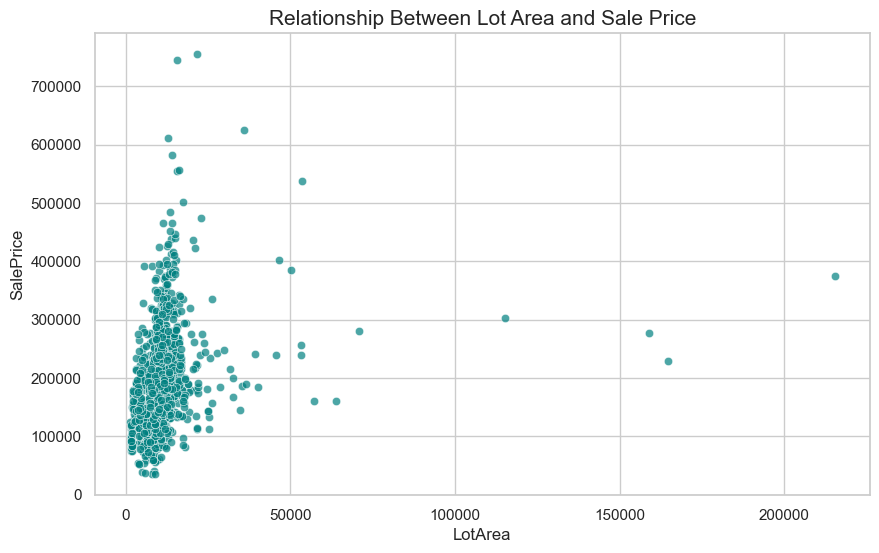

In [89]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='LotArea', y='SalePrice', data=df, color='teal', alpha=0.7)

# Add titles and labels
plt.title('Relationship Between Lot Area and Sale Price', fontsize=15)
plt.xlabel('LotArea', fontsize=12)
plt.ylabel('SalePrice', fontsize=12)

# Display the plot
plt.show()

#### 2. IQR (Interquartile Range)

In [91]:
import numpy as np

In [97]:
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3-Q1
    lower_Fence = Q1 - 1.5 * IQR
    upper_Fence = Q1 + 1.5 * IQR
    outliers = data[(data[col]< lower_Fence ) | (data[col] > upper_Fence)]

    return outliers[[col]]

In [98]:
outliers_salesprice = detect_outliers(df, "SalePrice")

In [ ]:
print(f"Number of outliers in sales price is : {len(outliers_salesprice)}")
display(outliers_salesprice.head())

no of outliers in sales price is : 203


,SalePrice
6,307000
11,345000
13,279500
20,325300
25,256300


### How to check if data is normally distributed

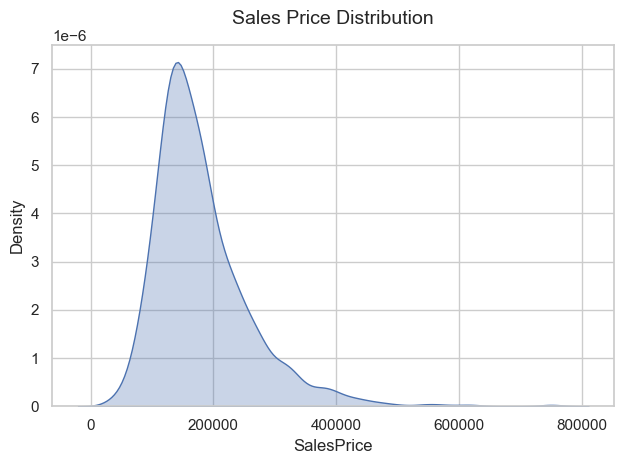

In [100]:
# Set a clean visual style
sns.set_style("whitegrid")
plt.Figure(figsize=(10,5))

sns.kdeplot(df["SalePrice"], label = "Original", fill= True, alpha=0.3)

# Enhancing readability
plt.title("Sales Price Distribution", fontsize=14, pad=15)
plt.xlabel("SalesPrice")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

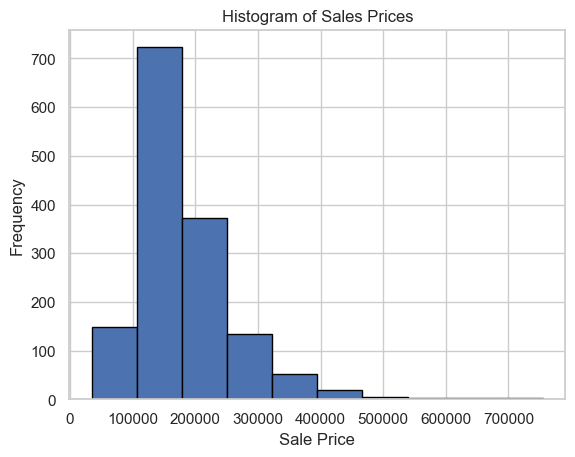

In [105]:
## using histogram
plt.hist(df["SalePrice"], bins=10, edgecolor="black")

plt.title("Histogram of Sales Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

##### Q-Q Plot

-  if points follow a diagonal line data is normal

In [102]:
import scipy.stats  as stats

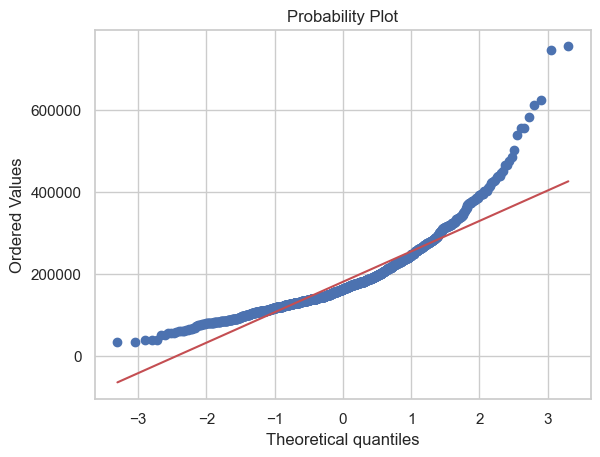

In [103]:
## Q-Q Plot

# if points follow a diagonal line data is normal

stats.probplot(df["SalePrice"], dist="norm", plot=plt)
plt.show()

##### Shapiro-Wilk Test

In [ ]:
## Shapiro-Wilk Test

l = 0.05 # as alpha

# H0 is : value < p ---> data is normal
# H1 is : value > p ---> data is not normal

stat, p = stats.shapiro(df["SalePrice"])
print("Shapiro-wilk Test p-value : ", p)
if p>l:
    print("Data looks normal")
else:
    print("Data is NOT normal")

Shapiro-wilk Test p-value :  3.2061412312021656e-33
Data is NOT normal


In [106]:
from scipy.stats import zscore

In [ ]:
df["SalePrice_z"] = zscore(df["SalePrice"])
outliers_z = df[df["SalePrice_z"].abs()> 3] ## ideal to use z-score of 3 and can be change to different number either higher or lower

In [109]:
print(f"Number of Outliers in SalesPrince (z-score) :", {len(outliers_z)})
outliers_z[["SalePrice", "SalePrice_z"]].head()

Number of Outliers in SalesPrince (z-score) : {22}


,SalePrice,SalePrice_z
58,438780,3.246967
178,501837,4.040982
185,475000,3.703050
349,437154,3.226492
389,426000,3.086040


In [110]:
df["SalePrice_z"] = zscore(df["SalePrice"])
outliers_z = df[df["SalePrice_z"].abs()> 4] ## ideal to use z-score of 3 and can be change to different number either higher or lower

In [111]:
print(f"Number of Outliers in SalesPrince (z-score) :", {len(outliers_z)})
outliers_z[["SalePrice", "SalePrice_z"]].head()

Number of Outliers in SalesPrince (z-score) : {9}


,SalePrice,SalePrice_z
178,501837,4.040982
440,555000,4.710413
691,755000,7.228819
769,538000,4.496348
803,582933,5.062146


In [112]:
df["SalePrice_z"] = zscore(df["SalePrice"])
outliers_z = df[df["SalePrice_z"].abs()> 5]

In [113]:
print(f"Number of Outliers in SalesPrince (z-score) :", {len(outliers_z)})
outliers_z[["SalePrice", "SalePrice_z"]].head()

Number of Outliers in SalesPrince (z-score) : {5}


,SalePrice,SalePrice_z
691,755000,7.228819
803,582933,5.062146
898,611657,5.423840
1169,625000,5.591855
1182,745000,7.102899
